# <center>Motivation</center>

<p align="justify">Diabetes is, in fact, a global epidemic. Millions of individuals live with undiagnosed or poorly managed diabetes, leading to severe complications such as cardiovascular disease, kidney failure, blindness, and lower-limb amputation. Knowing and preventing more this disease is, indeed, a high important task.</p>

<p align="justify">Thus, before we try to create any machine learning model, we need to not only handle inconsistencies, cleanning or droping imbalanced classes, but most important to understand more about the relations between the features. After all that, then we could proceede to creating a machine learning classification algoritm.</p>

## 1) Importing libraries

<p align="justify">In order to create a machine learning model that can estimates whether a patient has or has not tendencies with diabetes, we need to import libraries that can handle machine learning and data analysis workflows.</p>

<ul>
    <li>Third party packages:
        <ul>
            <li>
                <b><a href = "https://matplotlib.org/stable/index.html" target="blank">matplotlib</a></b>: to customize and create our own graphs in order to understand the data;
            </li>
            <li>
                <b><a href = "https://seaborn.pydata.org/" target="blank">seaborn</a></b>: to help create more specific data graphs less easily;
            </li>
            <li>
                <b><a href = "https://numpy.org/doc/stable/" target="blank">numpy</a></b>: to work and handle data more efficiently;
            </li>
            <li>
                <b><a href = "https://docs.pola.rs/api/python/stable/reference/index.html" target="blank">polars</a></b>: for fast data manipulation;
            </li>
            <li>
                <b><a href = "https://scikit-learn.org/stable/">scikit-learn</a></b>: for data algoritms;
            </li>
            <li>
                    <b><a href = "https://docs.scipy.org/doc/scipy/reference/stats.html" target="blank">scipy</a></b>: for statistic functions.;
            </li>
        </ul>
    </li>
    <li>Functions:
        <ul>
            <li>
                <b><a href = "./functions/plots.py" target="blank">plots</a></b>: to help create plots already determined;
            </li>
        </ul>
    </li>
</ul>

In [1]:
from matplotlib.colors import LinearSegmentedColormap
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, PowerTransformer, QuantileTransformer, RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import numpy as np
import scipy

from functions import plots

## 2) Reading dataset

### 2.1) Overview

<p align="justify">The Behavioral Risk Factor Surveillance System (<b>BRFSS</b>) is a health-related telephone survey that is collected annually by the Centers for Disease Control (<b>CDC</b>).</p>

<p align="justify">Each year, the survey collects responses from over 400,000 Americans on health-related risk behaviors, chronic health conditions, and the use of preventative services. It has been conducted every year since 1984. For this project, we will use a 2015 dataset available on <a href="https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset"><b>Kaggle</b></a>.</p>

#### 2.1.1) Understanding columns

<p align="justify">The dataset was already been cleanned before, therefore, some columns also has already been transformed to the point where some categorical values are now or binary or integers expressing some ordering. Luckily for us, the <b><a href="https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset/discussion/295407">Kaggle community</a></b> already have had a discussion about the meaning of each columns.</p>

<p align="justify">After reading the forum, we could rewrite each parameter as:</p>
<br>
<small>
<table>
  <thead>
    <tr>
      <th style="text-align: left;">Feature</th>
      <th style="text-align: left;">Type</th>
      <th style="text-align: left;">Meaning</th>
      <th style="text-align: left;">Values</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Diabetes_012</td>
      <td>Categorical</td>
      <td>Indicates if the patient has diabetes or pre-diabetes.</td>
      <td>0 = No diabetes; 1 = Pre-diabetes; 2 = Diabetes</td>
    </tr>
    <tr>
      <td>HighBP</td>
      <td>Categorical</td>
      <td>High blood pressure (as told by a health professional).</td>
      <td>0 = No; 1 = Yes</td>
    </tr>
    <tr>
      <td>HighChol</td>
      <td>Categorical</td>
      <td>High cholesterol (as told by a health professional).</td>
      <td>0 = No; 1 = Yes</td>
    </tr>
    <tr>
      <td>CholCheck</td>
      <td>Categorical</td>
      <td>Cholesterol check within the last 5 years.</td>
      <td>0 = No; 1 = Yes</td>
    </tr>
    <tr>
      <td>BMI</td>
      <td>Float</td>
      <td>Body Mass Index.</td>
      <td>Numerical value (e.g., 28.5)</td>
    </tr>
    <tr>
      <td>Smoker</td>
      <td>Categorical</td>
      <td>Have smoked at least 100 cigarettes in your entire life.</td>
      <td>0 = No; 1 = Yes</td>
    </tr>
    <tr>
      <td>Stroke</td>
      <td>Categorical</td>
      <td>Ever told you had a stroke.</td>
      <td>0 = No; 1 = Yes</td>
    </tr>
    <tr>
      <td>HeartDiseaseorAttack</td>
      <td>Categorical</td>
      <td>Coronary heart disease (CHD) or myocardial infarction (MI).</td>
      <td>0 = No; 1 = Yes</td>
    </tr>
    <tr>
      <td>PhysActivity</td>
      <td>Categorical</td>
      <td>Physical activity in past 30 days (excluding job).</td>
      <td>0 = No; 1 = Yes</td>
    </tr>
    <tr>
      <td>Fruits</td>
      <td>Categorical</td>
      <td>Consume fruit 1 or more times per day.</td>
      <td>0 = No; 1 = Yes</td>
    </tr>
    <tr>
      <td>Veggies</td>
      <td>Categorical</td>
      <td>Consume vegetables 1 or more times per day.</td>
      <td>0 = No; 1 = Yes</td>
    </tr>
    <tr>
      <td>HvyAlcoholConsump</td>
      <td>Categorical</td>
      <td>Heavy drinkers (Men >14 drinks/week; Women >7 drinks/week).</td>
      <td>0 = No; 1 = Yes</td>
    </tr>
    <tr>
      <td>AnyHealthcare</td>
      <td>Categorical</td>
      <td>Have any kind of health care coverage.</td>
      <td>0 = No; 1 = Yes</td>
    </tr>
    <tr>
      <td>NoDocbcCost</td>
      <td>Categorical</td>
      <td>Was there a time in past 12 months you needed a doctor but could not see one because of cost?</td>
      <td>0 = No; 1 = Yes</td>
    </tr>
    <tr>
      <td>GenHlth</td>
      <td>Categorical</td>
      <td>Self-reported general health on a scale of 1-5.</td>
      <td>1 = Excellent; 2 = Very good; 3 = Good; 4 = Fair; 5 = Poor</td>
    </tr>
    <tr>
      <td>MentHlth</td>
      <td>Integer</td>
      <td>Number of days of poor mental health in the last 30 days.</td>
      <td>Scale 0 - 30</td>
    </tr>
    <tr>
      <td>PhysHlth</td>
      <td>Integer</td>
      <td>Number of days of physical illness or injury in the last 30 days.</td>
      <td>Scale 0 - 30</td>
    </tr>
    <tr>
      <td>DiffWalk</td>
      <td>Categorical</td>
      <td>Serious difficulty walking or climbing stairs.</td>
      <td>0 = No; 1 = Yes</td>
    </tr>
    <tr>
      <td>Sex</td>
      <td>Categorical</td>
      <td>Biological sex.</td>
      <td>0 = Female; 1 = Male</td>
    </tr>
    <tr>
      <td>Age</td>
      <td>Categorical</td>
      <td>13-level age category (5-year increments).</td>
      <td>1 = 18-24 up to 13 = 80 or older</td>
    </tr>
    <tr>
      <td>Education</td>
      <td>Categorical</td>
      <td>Education level scale.</td>
      <td>1 = Never attended school up to 6 = College graduate</td>
    </tr>
    <tr>
      <td>Income</td>
      <td>Categorical</td>
      <td>Annual household income scale.</td>
      <td>1 = <$10k up to 8 = >$75k</td>
    </tr>
  </tbody>
</table>
</small>
<br>
<p align="justify">This is important to know because we are aiming to create a model that can return whether a patient has or has not tendencies with diabetes. Thus, this dictionary is importante because we can now specify each feature correctly.</p>

In [2]:
dataset = pl.read_csv(
    source = "./data/diabetes.csv"
)

print(dataset.shape)
dataset.head(n = 2)

(253680, 22)


Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0


#### 2.1.2) Checkin <code>dtypes</code>

<p align="justify">Luckily, as we can see, there are not a single column with <code>null</code> values. However, most of the features or have a wrong <code>dtype</code> or do not have the most appropriate - in terms of space in memory - type associate with it.</p>

In [3]:
with pl.Config(tbl_rows = 25):
    display(
        dataset.glimpse(
            max_items_per_column = 3,
            return_type = "frame"
        ).with_columns(
            pl.Series(values=[
                dataset[column].null_count()
                for column in dataset.columns
            ]).alias("null_count")
        ).select(
            ["column", "dtype", "null_count", "values"]
        )
    )

column,dtype,null_count,values
str,str,i64,list[str]
"""Diabetes_012""","""f64""",0,"[""0.0"", ""0.0"", ""0.0""]"
"""HighBP""","""f64""",0,"[""1.0"", ""0.0"", ""1.0""]"
"""HighChol""","""f64""",0,"[""1.0"", ""0.0"", ""1.0""]"
"""CholCheck""","""f64""",0,"[""1.0"", ""0.0"", ""1.0""]"
"""BMI""","""f64""",0,"[""40.0"", ""25.0"", ""28.0""]"
"""Smoker""","""f64""",0,"[""1.0"", ""1.0"", ""0.0""]"
"""Stroke""","""f64""",0,"[""0.0"", ""0.0"", ""0.0""]"
"""HeartDiseaseorAttack""","""f64""",0,"[""0.0"", ""0.0"", ""0.0""]"
"""PhysActivity""","""f64""",0,"[""0.0"", ""1.0"", ""0.0""]"


In [4]:
# Getting a estimated size of the dataset in Megabytes (mb):
print(
    f"Estimated dataframe size: {dataset.estimated_size(unit = 'megabytes'):.3f}Mb"
)

Estimated dataframe size: 42.579Mb


### 2.2) Setting correct values

<p align="justify">As we saw on top, mainly on those columns that represent a categorical non boolean feature, we need to replace preprocessing values in order to make our dataset more understandable. For those features that have boolean caracteristics, we are just going to replace to <code>True</code> and <code>False</code>.</p>

<p align="justify">For personal preference, we are also going to rename some columns in order to really have a more presentable dataset, even though that is not necessary.</p>

#### 2.2.1) Setting categorical columns values

In [5]:
categorical_columns = {
    "GenHlth": {
        "values": [1, 2, 3, 4, 5],
        "categories": ["excelent", "very_good", "good", "fair", "poor"],
        "new_name": "HEALTH_LEVEL",
    },
    "Sex": {
        "values": [0, 1],
        "categories": ["female", "male"],
        "new_name": "SEX",
    },
    "Age": {
        "values": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
        "categories": ["18_24", "25_29", "30_34", "35_39", "40_44", "45_49", "50_54", "55_59", "60_64", "65_69", "70_74", "75_79", "80_more"],
        "new_name": "AGE_RANGE",
    },
    "Education": {
        "values": [1, 2, 3, 4, 5, 6],
        "categories": ["not_educated", "elementary", "high_school_incompleted", "high_school_completed", "college_graduate_incompleted", "college_graduate_completed"],
        "new_name": "EDUCATION_LEVEL",
    },
    "Income": {
        "values": [1, 2, 3, 4, 5, 6, 7, 8],
        "categories": ["10k_less", "10K_15k", "15k_20k", "20k_25k", "25k_35k", "35k_50k", "50k_75k", "75K_more"],
        "new_name": "INCOME_RANGE",
    },
    "Diabetes_012": {
        "values": [0, 1, 2],
        "categories": ["no_diabetes", "pre_diabetes", "diabetes"],
        "new_name": "DIABETES_LEVEL",
    }
}

#### 2.2.2) Setting boolean columns values

In [6]:
boolean_columns = [
    ("HighBP", "HIGHT_BLOOD_PRESURE"),
    ("HighChol", "HAS_HIGHT_CHOLESTEROL"),
    ("CholCheck", "HAS_CHECKED_CHOLESTEROL"),
    ("Smoker", "IS_SMOKER"),
    ("Stroke", "HAD_STROKE"),
    ("HeartDiseaseorAttack", "HAD_HEARTH_ATTACK_OR_DISEASE"),
    ("PhysActivity", "HAVE_EXERCISED"),
    ("Fruits", "HAD_FRUITS"),
    ("Veggies", "HAD_VEGGIES"),
    ("HvyAlcoholConsump", "CONSUME_ALCOOL"),
    ("AnyHealthcare", "HAS_HEALTHCARE"),
    ("NoDocbcCost", "NO_DOCTOR_APPOINTMENT_BY_COST"),
    ("DiffWalk", "WALK_DIFFICULTY"),
]

#### 2.2.3) Setting number columns

In [7]:
float_columns = {
    "BMI": {
        "new_name": "BODY_MASS",
        "type": pl.Float16,
    },
    "MentHlth": {
        "new_name": "DAYS_BAD_MENTAL_HEALTH",
        "type": pl.Int8,
    },
    "PhysHlth": {
        "new_name": "DAYS_INJURY",
        "type": pl.Int8,
    }
}

#### 2.2.4) Getting <code>dtypes</code> correctly

In [8]:
# Setting boolean values correctly:
for item in boolean_columns:
    dataset = dataset.with_columns(
        pl.col(item[0]).cast(pl.Boolean).alias(item[1])
    ).drop(item[0])

# Setting float values correctly:
for column, values in float_columns.items():
    dataset = dataset.with_columns(
        pl.col(column).cast(
            dtype = values["type"]
        ).alias(
            name = values["new_name"]
        )
    ).drop(
        column
    )

# Setting categorical values correctly:
for column, value in categorical_columns.items():

    dataset = dataset.with_columns(
        pl.col(column)
            .cast(pl.Int8)
            .replace_strict(
                dict(
                    zip(
                        value["values"], value["categories"]
                    )
                ),
                default = None,
                return_dtype = pl.Enum(value["categories"])
            )
            .alias(value["new_name"])
        ).drop(
            column
        )

#### 2.2.5) View new dataset

In [9]:
with pl.Config(tbl_rows = 25):
    display(
        dataset.glimpse(
            max_items_per_column = 3,
            return_type = "frame"
        ).with_columns(
            pl.Series(values=[
                dataset[column].null_count()
                for column in dataset.columns
            ]).alias("null_count")
        ).select(
            ["column", "dtype", "null_count", "values"]
        )
    )

column,dtype,null_count,values
str,str,i64,list[str]
"""HIGHT_BLOOD_PRESURE""","""bool""",0,"[""True"", ""False"", ""True""]"
"""HAS_HIGHT_CHOLESTEROL""","""bool""",0,"[""True"", ""False"", ""True""]"
"""HAS_CHECKED_CHOLESTEROL""","""bool""",0,"[""True"", ""False"", ""True""]"
"""IS_SMOKER""","""bool""",0,"[""True"", ""True"", ""False""]"
"""HAD_STROKE""","""bool""",0,"[""False"", ""False"", ""False""]"
"""HAD_HEARTH_ATTACK_OR_DISEASE""","""bool""",0,"[""False"", ""False"", ""False""]"
"""HAVE_EXERCISED""","""bool""",0,"[""False"", ""True"", ""False""]"
"""HAD_FRUITS""","""bool""",0,"[""False"", ""False"", ""True""]"
"""HAD_VEGGIES""","""bool""",0,"[""True"", ""False"", ""False""]"


In [10]:
# Getting a estimated size of the dataset in Megabytes (mb):
print(
    f"Estimated dataframe size: {dataset.estimated_size(unit = 'megabytes'):.3f}Mb"
)

Estimated dataframe size: 2.813Mb


## 3) Understanding dataset

<p align="justify">In order to get a more understanding knowledge about the data that we are handling here, we need to check if there are, for example, outliers or any other patterns that could be used in our favor. Therefore, we are going to split this section according to the list bellow:</p>

<ol align="justify">
    <li><b>Seeing imbalance</b>: since <code>DIABETES_LEVEL</code> is the target feature, it could have minority values that needs to be handled properly;</li>
    <li><b>Correlations</b>: checking if there are any kind or degree of correlation with our target feature (<code>DIABETES_LEVEL</code>);</li>
    <li><b>Importance Value</b>: checking if there are any columns that have a high importance with target feature (<code>DIABETES_LEVEL</code>);</li>
    <li><b>Checking data normalization</b>: checking if columns with number values have a normal distribution;</li>
    <li><b>Searching outliers</b>: try to get outliers based again on columns with number values;</li>
</ol>

### 3.1) Seeing imbalance

<p align="justify">As we can see, we have three diferents categories in <code>DIABETES_LEVEL</code>: <i>no_diabetes</i>, <i>pre_diabetes</i> and <i>diabetes</i>. In our case, we are trying to figure out if a certain person has or do not has diabetes.</p>

#### 3.1.1) Visualizing imbalance

<p align="justify">Therefore, we will create a simple dual plot that shows us the percentage amoung those categories in the target column <code>DIABETES_LEVEL</code>.</p>

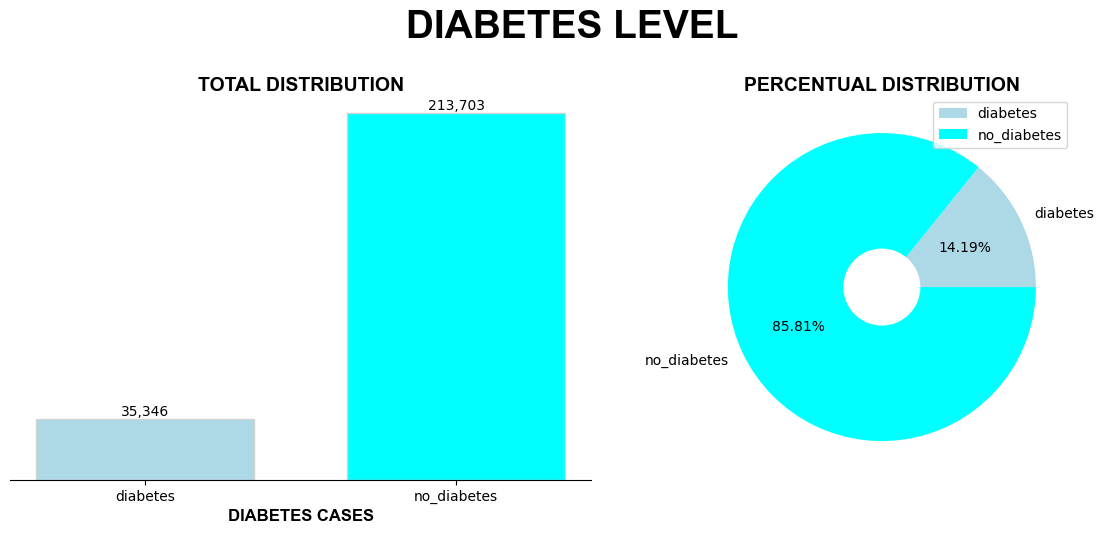

In [81]:
fig, axs = plt.subplots(
    figsize = (15, 5),
    ncols = 2,
    gridspec_kw = {
        "wspace": .0
    }
)

# Getting total and relative frequency for each category in DIABETES_LEVEL:
plot_df = dataset.group_by(
    ["DIABETES_LEVEL"]
).agg(
    pl.col("DIABETES_LEVEL").len().cast(pl.Int32).alias("TOTAL")
).with_columns(
    (pl.col("TOTAL")/pl.col("TOTAL").sum()).alias("PERCENTAGE")
).sort(
    "TOTAL"
)

# Setting a bar plot for total cases in DIABETES_LEVEL
plots.plot_bar(
    ax = axs[0],
    x_values = plot_df["DIABETES_LEVEL"],
    y_values = plot_df["TOTAL"],
    colors = ["lightblue", "cyan", "darkcyan"],
    legends = plot_df["DIABETES_LEVEL"],
    formater = "{:,.0f}",
    title = {
        "text": f"TOTAL DISTRIBUTION",
        "font": "arial",
        "size": 14,
    },
    x_label = {
        "text": "DIABETES CASES",
        "font": "arial",
        "size": 12,
    },
    y_label = {
        "text": "",
        "font": "arial",
        "size": 12
    },
    width = .7,
    tooltip_align = "edge"
)

# Setting a pie plot for percentual cases in DIABETES_LEVEL:
plots.plot_pie(
    ax = axs[1],
    values = plot_df["PERCENTAGE"],
    labels = plot_df["DIABETES_LEVEL"],
    colors = ["lightblue", "cyan", "darkcyan"],
    title = {
        "text": f"PERCENTUAL DISTRIBUTION",
        "font": "arial",
        "size": 14,
    },
)

plt.legend()
plt.suptitle("DIABETES LEVEL", fontsize = 28, y = 1.05, fontname = "arial", fontweight = "bold")
plt.show()

#### 3.1.2) Droping <code>pre_diabetes</code> registers

<p align="justify">As we saw on top, we only have <code>1.83%</code> (which only corresponds to 4.631 rows) of <code>pre_diabetes</code> in the entire dataset (with 253.680 rows). Even though we understand that <code>pre_diabetes</code> is a also a serious condition, we decided to drop those registers not only because of the minor size, but also because the main goal of this project is to find out if a person has or has not diabetes.</p>

In [12]:
dataset = dataset.filter(
    pl.col("DIABETES_LEVEL") != "pre_diabetes"
)

# Getting a estimated size of the dataset in Megabytes (mb):
print(
    f"Estimated dataframe size: {dataset.estimated_size(unit = 'megabytes'):.3f}Mb"
)
print(dataset.shape)

Estimated dataframe size: 2.762Mb
(249049, 22)


### 3.2) Correlations

<p align="justify">Correlation in a dataset could cause redundancies, and it is bad for machine learning because some features could have, for example, its importance multiply by other similar features. Furthermore, we need to seek correlations in our dataset and find a way to avoid vicious behaviour in our future model.</p>

#### 3.2.1) Visualizing correlations

<p align="justify">According to the interpretation of the module of index correlation bellow, we do not find a single value between the range <b><mrow>[0.70, 1.00]</mrow></b>, with indicate us that all features are - in some way - independent. However, there are some cases where some features can reach [0.30, 0.50] or even [0.50, 0.70] range correlation, which needs in fact more exploration.</p>

<center>
    <table>
        <thead>
            <tr>
                <th><center>RANGE</center></th>
                <th><center>CORRELATION LEVEL</center></th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td>0.00 - 0.10</td>
                <td>inexistent</td>
            </tr>
            <tr>
                <td>0.10 - 0.30</td>
                <td>weak</td>
            </tr>
            <tr>
                <td>0.30 - 0.50</td>
                <td>moderate</td>
            </tr>
            <tr>
                <td>0.50 - 0.70</td>
                <td>high</td>
            </tr>
            <tr>
                <td>0.70 - 1.00</td>
                <td>very high</td>
            </tr>
        </tbody>
    </table>
</center>

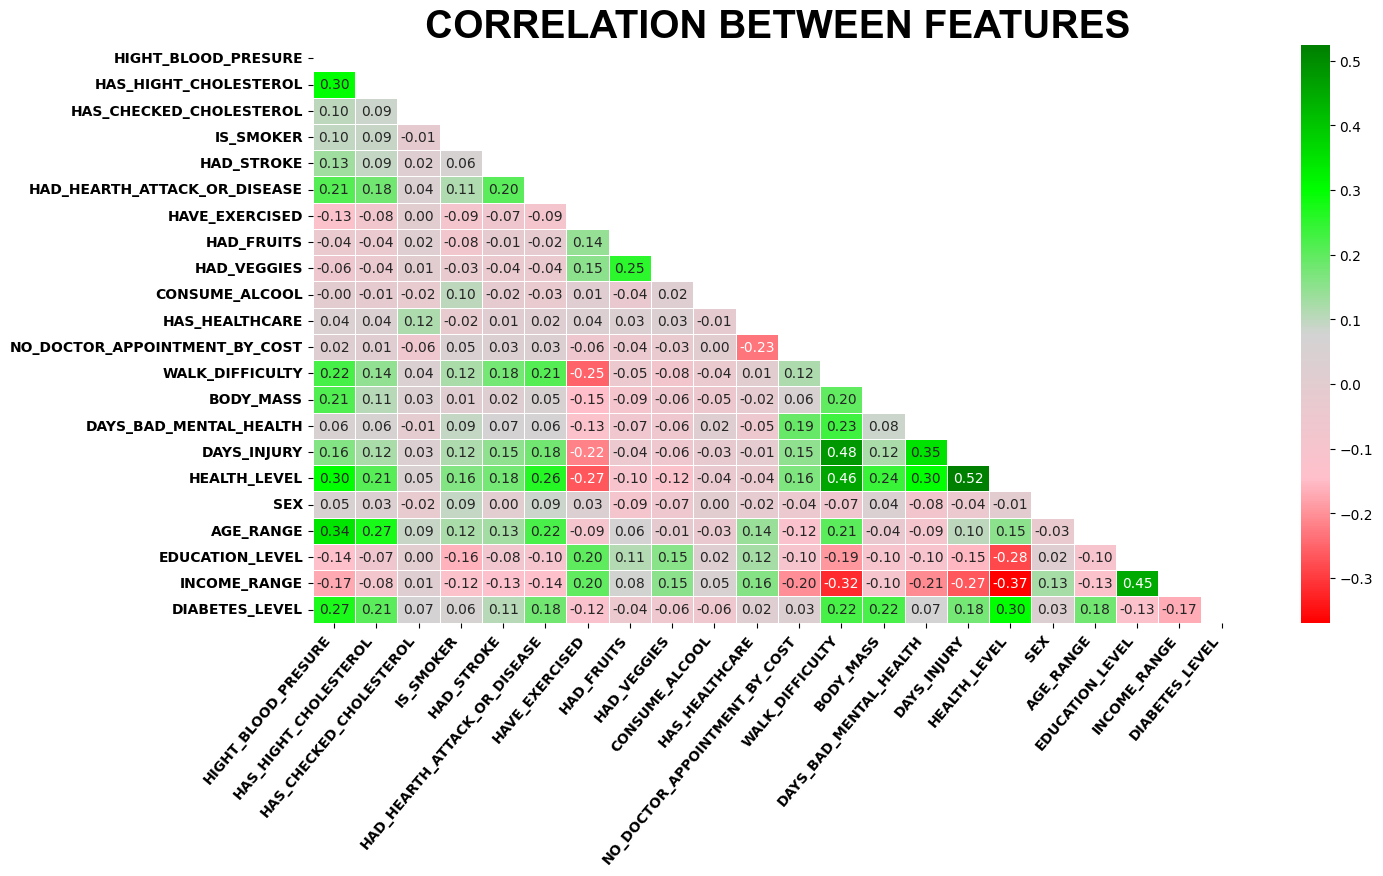

In [13]:
fig, ax = plt.subplots(
    figsize = (15, 7.5),
)

corr_dataset = dataset.with_columns(
    pl.col(pl.Enum).to_physical()
).corr()

plots.plot_heatmap(
    ax = ax,
    corr_dataset = corr_dataset,
    title = {
        "text": "CORRELATION BETWEEN FEATURES",
        "size": 28
    },
    haxticks= "right",
    hayticks = "right"
)

plt.show()

#### 3.2.2) Handling strong correlation

##### 3.2.2.A) Ploting correlation

<p align="justify">As we saw on top, <code>DAYS_INJURY</code>, <code>HEALTH_LEVEL</code> and <code>WALK_DIFFICULTY</code> are the ones who have a similar and strong correlation, even though is not strong enough to assume that all features are the same. Since each feature has a specific <code>dtype</code>, we are force to use other plot than the standart scatter plot. Let's see how much each variable behave with each other.</p>

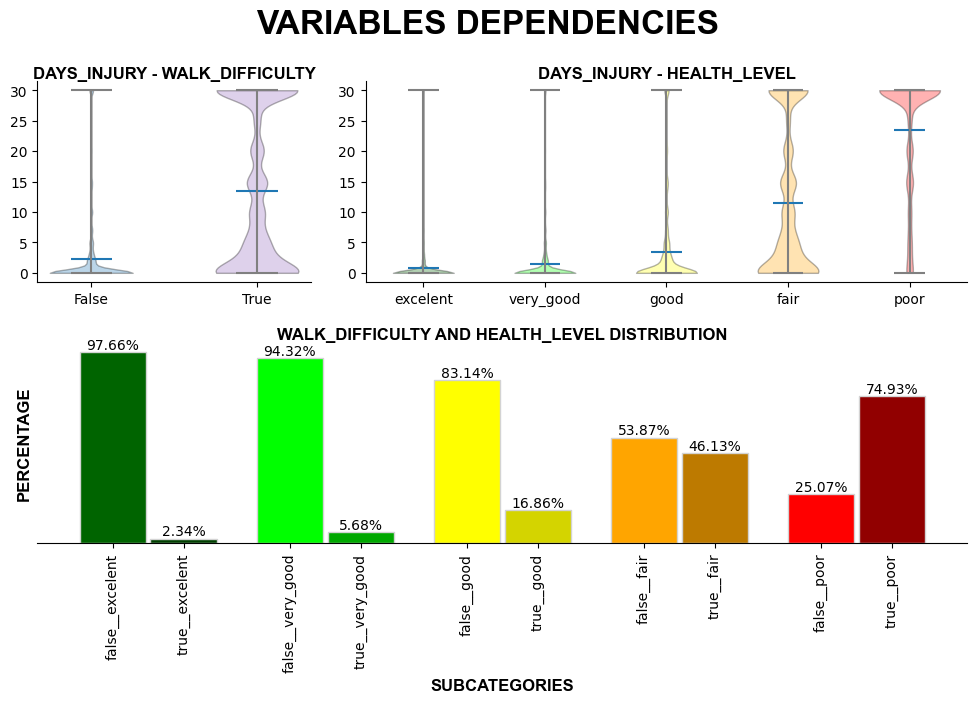

In [121]:
fig, axs = plt.subplot_mosaic(
    mosaic = [["WALK_DIFFICULTY", "HEALTH_LEVEL", "HEALTH_LEVEL"], ["WALK_DIFFICULTY_HEALTH_LEVEL"]*3],
    figsize = (12, 6),
    gridspec_kw = {
        "hspace": .3
    }
)

colors = [
    (
        "C0", "C4",
    ), (
        "darkgreen", "lime", "yellow", "orange", "red"
    )
]

for index, column in enumerate(["WALK_DIFFICULTY", "HEALTH_LEVEL"]):

    values = dataset[column].unique()

    plots.plot_violin(
        ax = axs[column],
        data = [
            dataset.filter(
                pl.col(column) == value
            )["DAYS_INJURY"] for value in values
        ],
        colors = colors[index],
        title = {
            "text": f"DAYS_INJURY - {column}"
        }
    )

    axs[column].set_xticks(
        ticks = range(1, len(values) + 1),
        labels = values
    )

plotdf = dataset.group_by(
    ["WALK_DIFFICULTY", "HEALTH_LEVEL"]
).agg(
    pl.col("HEALTH_LEVEL").len().alias("TOTAL")
).sort(
    by = ["HEALTH_LEVEL", "WALK_DIFFICULTY"]
).with_columns(
    (
        pl.col("WALK_DIFFICULTY") + "__" + pl.col("HEALTH_LEVEL")
    ).alias("WALK_DIFFICULTY_HEALTH_LEVEL"),
    (
        pl.col("TOTAL")/pl.col("TOTAL").sum().over("HEALTH_LEVEL")
    ).alias("PERCENTAGE")
)

positions = [0.1, 0.9, 2.1, 2.9, 4.1, 4.9, 6.1, 6.9, 8.1, 8.9]

plots.plot_bar(
    ax = axs["WALK_DIFFICULTY_HEALTH_LEVEL"],
    x_values = positions,
    y_values = plotdf["PERCENTAGE"],
    title = {
        "text": "WALK_DIFFICULTY AND HEALTH_LEVEL DISTRIBUTION",
    },
    x_label = {
        "text": "SUBCATEGORIES",
    },
    y_label = {
        "text": "PERCENTAGE",
    },
    colors =  ["darkgreen", "#004000", "lime", "#00A800", "yellow", "#D4D400", "orange", "#BD7A00", "red", "#910000"],
    legends = plotdf["WALK_DIFFICULTY_HEALTH_LEVEL"],
    formater = "{:,.2%}",
    tooltip_align = "edge",
    width = .75
)

axs["WALK_DIFFICULTY_HEALTH_LEVEL"].tick_params(axis='x', labelrotation=90)

axs["WALK_DIFFICULTY_HEALTH_LEVEL"].set_xticks(
    ticks = positions,
    labels = plotdf["WALK_DIFFICULTY_HEALTH_LEVEL"]
)

plt.suptitle(
    t = "VARIABLES DEPENDENCIES",
    fontsize = 24,
    fontweight = "bold",
    fontfamily = "arial",
    y = 1
)
plt.show()

<p align = "justify">As we saw on top, those features indeed have a positive correlation behaviour, even though it is not strong enough. Here is the overall interpretation:</p>

<ul>
    <li><b><code>WALK_DIFFICULTY</code> and <code>DAYS_INJURY</code></b>: people that confirms been walking difficulty usually tell that has been injuried for a longer period of time;</li>
    <li><b><code>HEALTH_LEVEL</code> and <code>DAYS_INJURY</code></b>: people that evalute themselfs poorly also tell that has been injuried for a longer period of time;</li>
    <li><b><code>WALK_DIFFICULTY</code> and <code>HEALTH_LEVEL</code></b>: as people report feeling worse, the response of difficulty walking gradually increases.</li>
</ul>

##### 3.2.2.C) Applying PCA

<p align="justify">PCA is a method used to simplify a number of n features into a m (m < n) features. It is very helpfull not only to reduce the size of the data, but it also can avoid redundancy in features that may have a high correlation. However, in order to apply any PCA transformations, we must have to have at least a more comparable standard deviation between these variables.</p>

In [123]:
dataset["WALK_DIFFICULTY", "HEALTH_LEVEL", "DAYS_INJURY"].with_columns(
    pl.col(pl.Enum).to_physical(),
    pl.col(pl.Boolean).cast(pl.Int8)
).describe().filter(
    pl.col("statistic") == "std"
)

statistic,WALK_DIFFICULTY,HEALTH_LEVEL,DAYS_INJURY
str,f64,f64,f64
"""std""",0.372254,1.067308,8.681035


<p align = "justify">In order words, we should transform <code>DAYS_INJURY</code> in order to have a standard deviation similar to what we have found after reducing categories in <code>HEALTH_LEVEL</code> (1.067) and <code>WALK_DIFFICULTY</code> (0.372).</p>

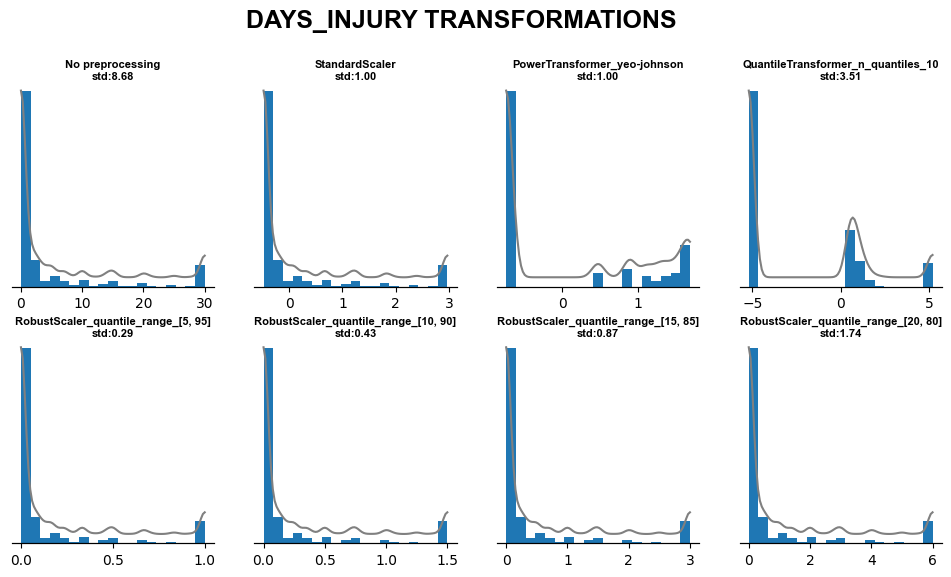

In [17]:
methods = [
    {
        "method": None,
        "name": "No preprocessing",
    },
    {
        "method": StandardScaler(),
        "name": "StandardScaler",
    },
    {
        "method": PowerTransformer(method = "yeo-johnson"),
        "name": "PowerTransformer_yeo-johnson",
    },
    {
        "method": QuantileTransformer(n_quantiles = 10, output_distribution="normal"),
        "name": "QuantileTransformer_n_quantiles_10"
    },
    {
        "method": RobustScaler(quantile_range = (5, 95)),
        "name": "RobustScaler_quantile_range_[5, 95]"
    },
    {
        "method": RobustScaler(quantile_range = (10, 90)),
        "name": "RobustScaler_quantile_range_[10, 90]"
    },
    {
        "method": RobustScaler(quantile_range = (15, 85)),
        "name": "RobustScaler_quantile_range_[15, 85]"
    },
    {
        "method": RobustScaler(quantile_range = (20, 80)),
        "name": "RobustScaler_quantile_range_[20, 80]"
    },
]

fig, axs = plt.subplots(
    ncols = 4,
    nrows = 2,
    figsize = (12, 6),
    gridspec_kw = {
        "hspace": 0.25
    }
)

axs = axs.flatten()

for index, item in enumerate(methods):

    result = item["method"].fit_transform(dataset["DAYS_INJURY"].to_numpy().reshape(-1, 1)).reshape(-1) if item["method"] != None else dataset["DAYS_INJURY"].to_numpy()

    plots.plot_histogram(
        ax = axs[index],
        values = result,
        title = {
            "text": f'{item["name"]}\nstd:{np.std(a = result):.2f}',
            "size": 8,
        },
        color = "C0",
        labels = "DAYS_INJURY",
        bins = "sturges",
        tooltip = {
            "show": False
        },
        kde = {
            "show": True,
            "color": "gray",
        },
        
    )

plt.suptitle(
    t = "DAYS_INJURY TRANSFORMATIONS",
    fontsize = 18,
    y = 1,
    fontweight = "bold",
    fontfamily = "arial"
)
plt.show()

<p align = "justigy">Therefore, we must have to transforme <code>DAYS_INJURY</code> using RobustScaler (10, 90) to have better and fair results using PCA:</p>

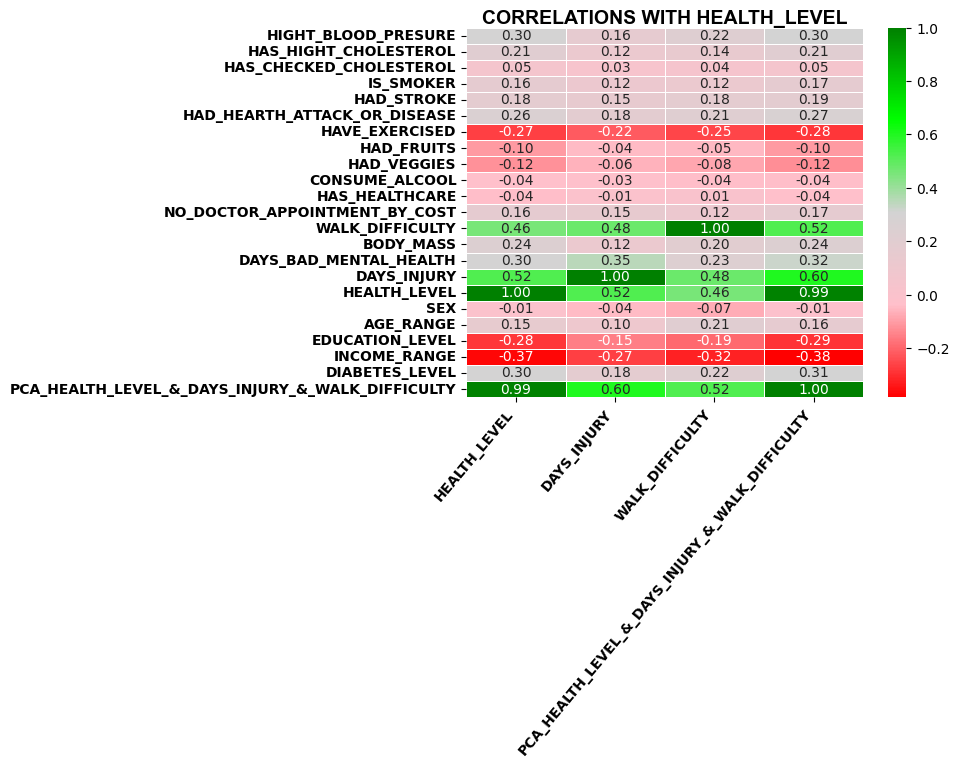

In [127]:
pca_transformer = PCA(
    n_components = 1
)

fig, ax = plt.subplots()

corr_dataset = dataset.with_columns(
    pl.lit(
        RobustScaler(
        quantile_range = (10, 90)
    ).fit_transform(dataset["DAYS_INJURY"].to_numpy().reshape(-1, 1)).reshape(-1)
    ).alias("DAYS_INJURY_PROCESSED")
)

corr_dataset = corr_dataset.with_columns(
    pl.col(pl.Enum).to_physical(),
    pl.lit(
        pca_transformer.fit_transform(
            corr_dataset.with_columns(
                pl.col(pl.Enum).to_physical()
            )[["DAYS_INJURY_PROCESSED", "HEALTH_LEVEL", "WALK_DIFFICULTY"]]
        ).reshape(-1)
    ).alias("PCA_HEALTH_LEVEL_&_DAYS_INJURY_&_WALK_DIFFICULTY")
).drop(
    ["DAYS_INJURY_PROCESSED"]
).corr()

plots.plot_heatmap(
    ax = ax,
    corr_dataset = corr_dataset[["HEALTH_LEVEL", "DAYS_INJURY", "WALK_DIFFICULTY", "PCA_HEALTH_LEVEL_&_DAYS_INJURY_&_WALK_DIFFICULTY"]],
    title = {
        "text": "CORRELATIONS WITH HEALTH_LEVEL",
        "size": 14,
    },
    yticklabels = corr_dataset.columns,
    xticksrotation = 50,
    haxticks = "right",
    hayticks = "right",
    hasMask = False
)

plt.show()

### 3.3) Importance Value

### 3.4) Checking data normalization

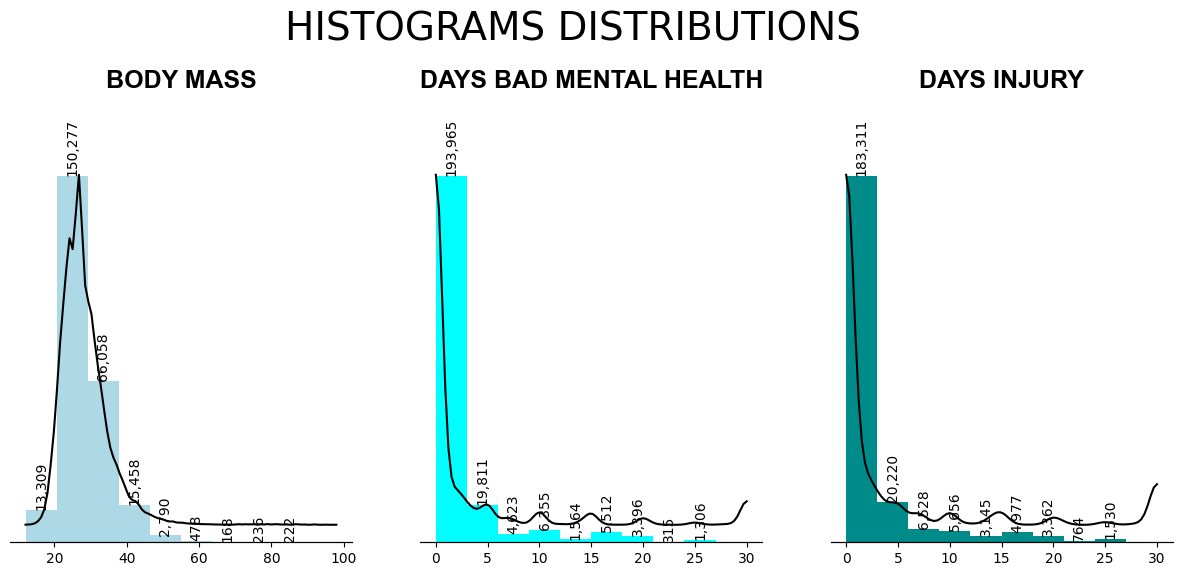

In [19]:
fig, axs = plt.subplots(
    ncols = 3,
    figsize = (15, 5),
    gridspec_kw = {
        "hspace": 0.5
    }
)

for index, column in enumerate(["BODY_MASS", "DAYS_BAD_MENTAL_HEALTH", "DAYS_INJURY"]):

    plots.plot_histogram(
        ax = axs[index],
        values = dataset[column],
        title = {
            "text": column.replace("_", " "),
            "size": 18,
            "pady": 50
        },
        bins = np.arange(
            dataset[column].min(), dataset[column].max(), (dataset[column].max() - dataset[column].min())/10
        ),
        tooltip = {
            "rotation": "vertical",
            "show": True,
            "horizontalalignment": "center",
            "verticalalignment": "bottom"
        },
        kde = {
            "show": True,
            "color": "black"
        },
        color = ["lightblue", "cyan", "darkcyan"][index],
        labels = ["BODY_MASS", "DAYS_BAD_MENTAL_HEALTH", "DAYS_INJURY"][index]
    )

plt.suptitle(
    t = "HISTOGRAMS DISTRIBUTIONS",
    fontsize = 28,
    y = 1.175
)
plt.show()

In [20]:
# ["BODY_MASS", "DAYS_BAD_MENTAL_HEALTH", "DAYS_INJURY"]
dataset["BODY_MASS"].skew()

2.136378977861183

In [21]:
dataset["BODY_MASS"].kurtosis()

11.139878819975223

In [22]:
dataset

HIGHT_BLOOD_PRESURE,HAS_HIGHT_CHOLESTEROL,HAS_CHECKED_CHOLESTEROL,IS_SMOKER,HAD_STROKE,HAD_HEARTH_ATTACK_OR_DISEASE,HAVE_EXERCISED,HAD_FRUITS,HAD_VEGGIES,CONSUME_ALCOOL,HAS_HEALTHCARE,NO_DOCTOR_APPOINTMENT_BY_COST,WALK_DIFFICULTY,BODY_MASS,DAYS_BAD_MENTAL_HEALTH,DAYS_INJURY,HEALTH_LEVEL,SEX,AGE_RANGE,EDUCATION_LEVEL,INCOME_RANGE,DIABETES_LEVEL
bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,f16,i8,i8,enum,enum,enum,enum,enum,enum
true,true,true,true,false,false,false,false,true,false,true,false,true,40.0,18,15,"""poor""","""female""","""60_64""","""high_school_completed""","""15k_20k""","""no_diabetes"""
false,false,false,true,false,false,true,false,false,false,false,true,false,25.0,0,0,"""good""","""female""","""50_54""","""college_graduate_completed""","""10k_less""","""no_diabetes"""
true,true,true,false,false,false,false,true,false,false,true,true,true,28.0,30,30,"""poor""","""female""","""60_64""","""high_school_completed""","""75K_more""","""no_diabetes"""
true,false,true,false,false,false,true,true,true,false,true,false,false,27.0,0,0,"""very_good""","""female""","""70_74""","""high_school_incompleted""","""35k_50k""","""no_diabetes"""
true,true,true,false,false,false,true,true,true,false,true,false,false,24.0,3,0,"""very_good""","""female""","""70_74""","""college_graduate_incompleted""","""20k_25k""","""no_diabetes"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
true,true,true,false,false,false,false,true,true,false,true,false,false,45.0,0,5,"""good""","""male""","""40_44""","""college_graduate_completed""","""50k_75k""","""no_diabetes"""
true,true,true,false,false,false,false,false,false,false,true,false,true,18.0,0,0,"""fair""","""female""","""70_74""","""elementary""","""20k_25k""","""diabetes"""
false,false,true,false,false,false,true,true,false,false,true,false,false,28.0,0,0,"""excelent""","""female""","""25_29""","""college_graduate_incompleted""","""10K_15k""","""no_diabetes"""
